In [2]:
import warnings

warnings.filterwarnings('ignore')

### Установим красивые дефолтные настройки
### Может быть лень постоянно прописывать
### У графиков параметры цвета, размера, шрифта
### Можно положить их в словарь дефолтных настроек

import matplotlib as mlp

mlp.rcParams['lines.linewidth'] = 5
mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.max_columns = 500

df = pd.read_csv("banking.csv")

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,210,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,138,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,339,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,185,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,137,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


In [5]:
df.shape

(41188, 21)

<dl>
<dt> Описание колонок:
<dd>age - возраст клиента </dd>
<dd>job - тип работы </dd>
<dd>marital - статус замужества</dd>
<dd>education - степень образования </dd>
<dd>default - дефолтил ли клиент? </dd>
<dd>housing - есть ли жилищный кредит? </dd>
<dd>loan - есть ли потребительский кредит? </dd>
<dd>contact - тип коммуникации </dd>
<dd>month - месяц последнего контакта </dd>
<dd>day_of_week - день недели последнего контакта </dd>
<dd>duration - длительность последнего звонка - стоит убрать при обучении модели </dd>
<dd>campaign - количество звонков в течение маркетинговой кампании </dd>
<dd>pdays - как давно не было коммуникации с клиентом, относительно предыдущей маркетинговой кампании </dd>
<dd>previous - количество звоноков до текущей маркетинговой компании </dd>
<dd>poutcome - результат предыдущей маркентинговой кампании относительно выбранного клиента </dd>
<dd>emp.var.rate - коэффициент вариации безработицы (quarterly) </dd>
<dd>cons.price.idx - индекс потребительских цен (monthly) </dd>
<dd>cons.conf.idx: - индекс потребительской уверенности (monthly) </dd>
<dd>euribor3m - межбанковская европейская ставка предложения по трехмесячному займу (daily) </dd>
<dd>nr.employed - количество занятых </dd>
<dd>y - таргетная переменная: взял ли клиент депозит </dd>
</dl>

**Наша целевая переменная - взял ли клиент депозит.**

In [6]:
df = df.drop('duration', axis=1)

In [7]:
numeric_columns = df.loc[:, df.dtypes != np.object_].columns
df.loc[:, df.dtypes != np.object_].head()

,age,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,1,999,0,1.4,93.444,-36.1,4.963,5228.1,0
1,53,1,999,0,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,3,6,2,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,2,999,0,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,1,3,1,-2.9,92.201,-31.4,0.869,5076.2,1


In [8]:
categorical_columns = df.loc[:, df.dtypes == np.object_].columns
df.loc[:, df.dtypes == np.object_].head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,nonexistent
1,technician,married,unknown,no,no,no,cellular,nov,fri,nonexistent
2,management,single,university.degree,no,yes,no,cellular,jun,thu,success
3,services,married,high.school,no,no,no,cellular,apr,fri,nonexistent
4,retired,married,basic.4y,no,yes,no,cellular,aug,fri,success


In [9]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

In [10]:
df.describe()

,age,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [11]:
df[numeric_columns].corr()

,age,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
age,1.000000,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725,0.030399
campaign,0.004594,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095,-0.066357
pdays,-0.034369,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605,-0.324914
previous,0.024365,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333,0.230181
emp_var_rate,-0.000371,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970,-0.298334
cons_price_idx,0.000857,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034,-0.136211
cons_conf_idx,0.129372,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513,0.054878
euribor3m,0.010767,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154,-0.307771
nr_employed,-0.017725,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000,-0.354678
y,0.030399,-0.066357,-0.324914,0.230181,-0.298334,-0.136211,0.054878,-0.307771,-0.354678,1.000000


<Axes: >

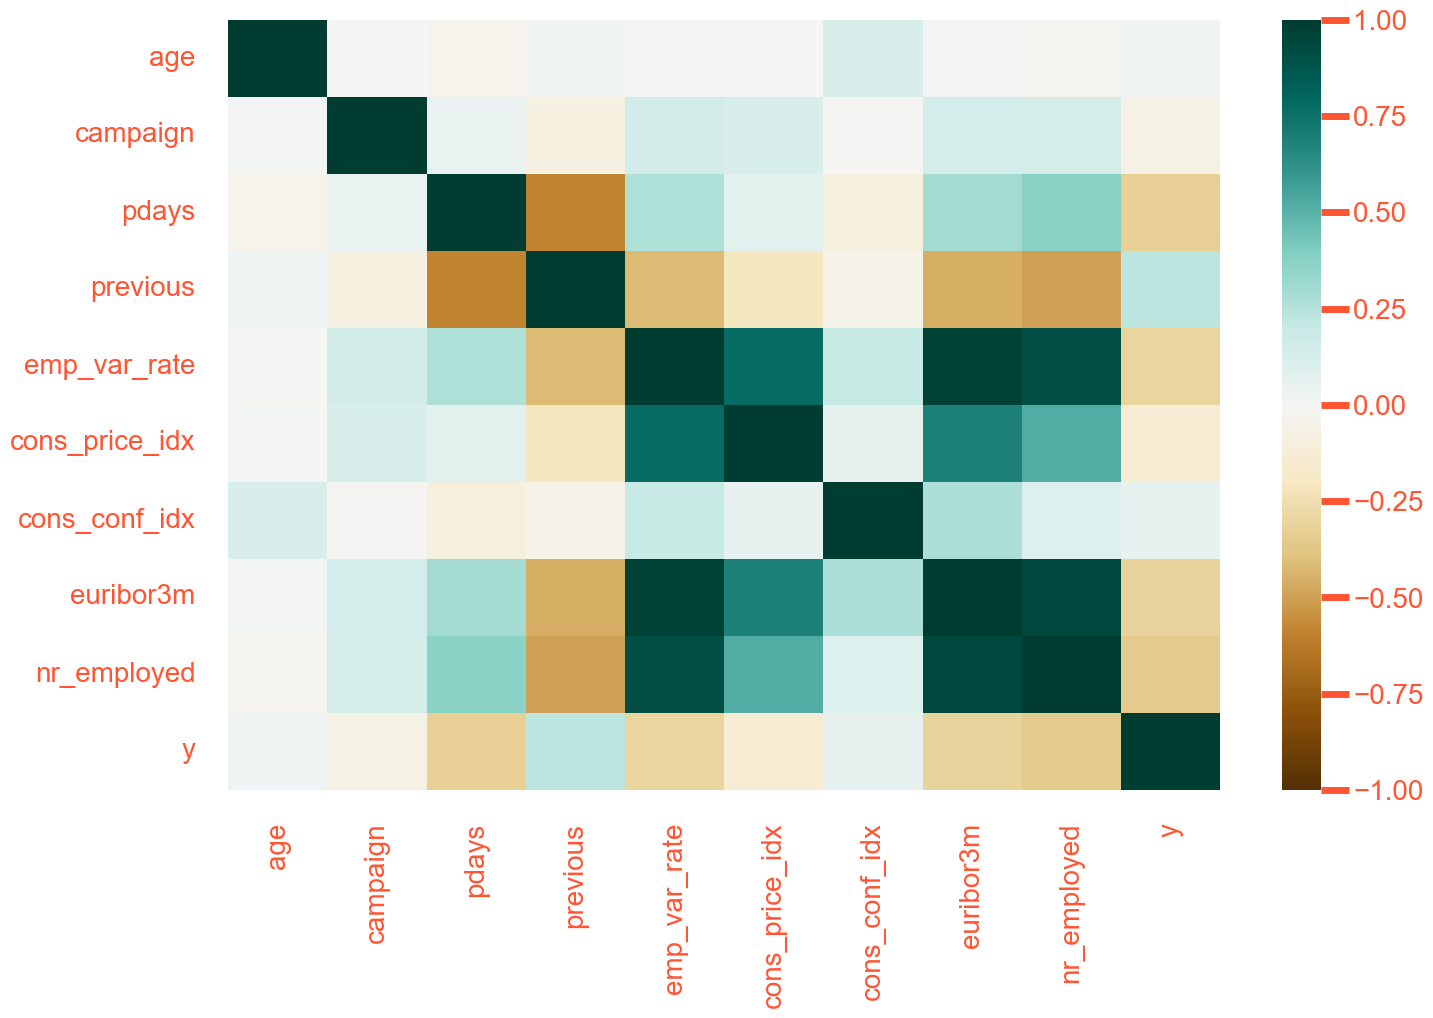

In [12]:
import seaborn as sns

fig = plt.figure()
fig.set_size_inches(16, 10)
sns.heatmap(df[numeric_columns].corr(), xticklabels=numeric_columns, yticklabels=numeric_columns, cmap='BrBG', vmin=-1,
            vmax=1)


In [13]:
### Секретные функции для фильтрации признаков

def get_redundant_pairs(df):
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i + 1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop


def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]


print("Top Absolute Correlations")
print(get_top_abs_correlations(df[numeric_columns], 10))

Top Absolute Correlations
emp_var_rate    euribor3m         0.972245
euribor3m       nr_employed       0.945154
emp_var_rate    nr_employed       0.906970
                cons_price_idx    0.775334
cons_price_idx  euribor3m         0.688230
pdays           previous          0.587514
cons_price_idx  nr_employed       0.522034
previous        nr_employed       0.501333
                euribor3m         0.454494
                emp_var_rate      0.420489
dtype: float64


In [14]:
test = df[numeric_columns].drop(['emp_var_rate', 'euribor3m'], axis=1)
get_top_abs_correlations(test, 10)

pdays           previous          0.587514
cons_price_idx  nr_employed       0.522034
previous        nr_employed       0.501333
pdays           nr_employed       0.372605
nr_employed     y                 0.354678
pdays           y                 0.324914
previous        y                 0.230181
                cons_price_idx    0.203130
campaign        nr_employed       0.144095
cons_price_idx  y                 0.136211
dtype: float64

In [15]:
df = df.drop(['emp_var_rate', 'euribor3m'], axis=1)
numeric_columns = numeric_columns.drop(['emp_var_rate', 'euribor3m'])

In [16]:
### Посмотрим на квазиконстантые признаки

from sklearn.feature_selection import VarianceThreshold

cutter = VarianceThreshold(threshold=0.1)
cutter.fit(df[numeric_columns])

cutter.get_feature_names_out()

array(['age', 'campaign', 'pdays', 'previous', 'cons_price_idx',
       'cons_conf_idx', 'nr_employed'], dtype=object)

In [17]:
numeric_columns

Index(['age', 'campaign', 'pdays', 'previous', 'cons_price_idx',
       'cons_conf_idx', 'nr_employed', 'y'],
      dtype='object')

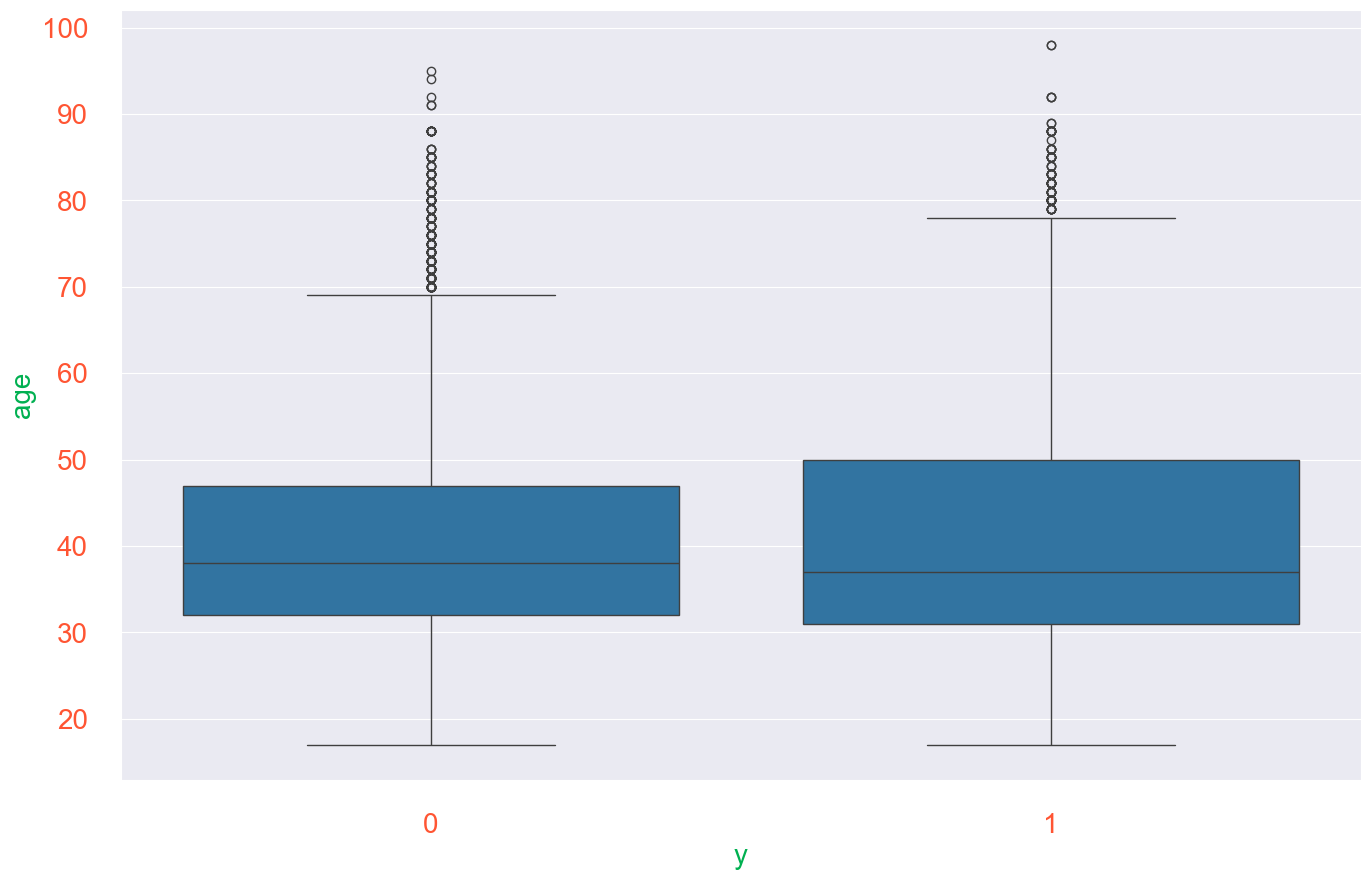

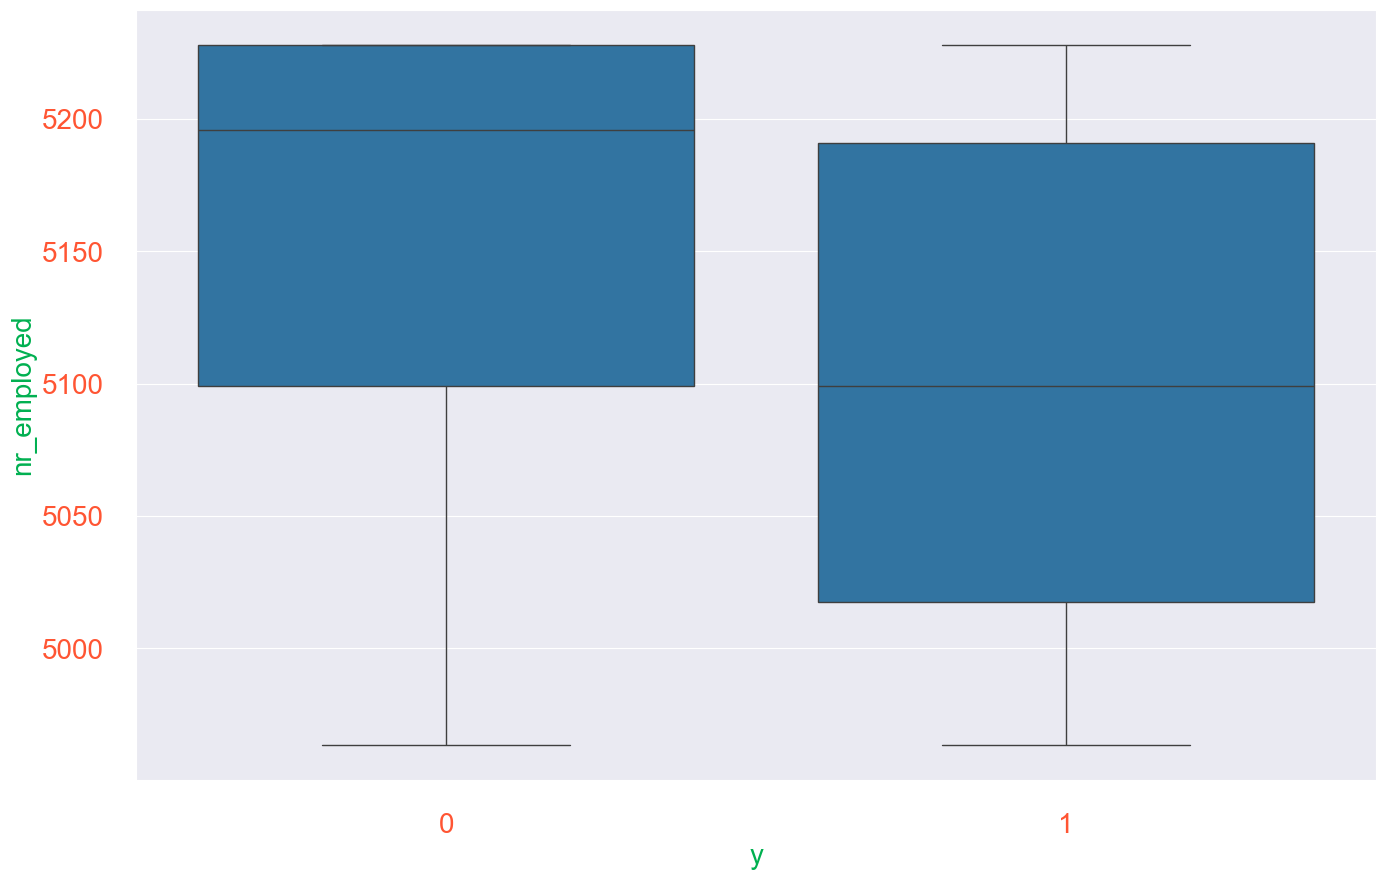

In [18]:
### Еще один способ, как в задаче классификации без построения модели
### оценить важность вещественных признаков- с помощью ящиков с усами!
### Только теперь немного "наоборот", представляя таргет как категорию
### А значения, распределение которых хотим сравнивать, окажутся нашими фичами

num_col = ['age', 'nr_employed']

for col in num_col:
    fig = plt.figure()
    fig.set_size_inches(16, 10)

    sns.boxplot(y=col, x=df['y'].astype('category'), data=df)
    fig.show()



In [19]:
### Посмотрим на распределение категорий среди разных таргетов

df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563


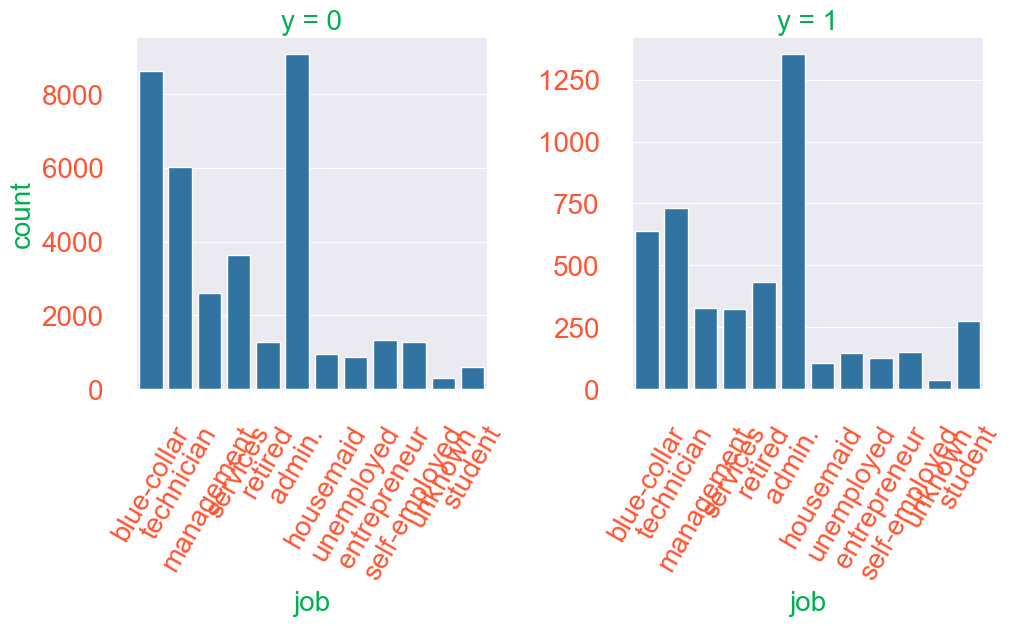

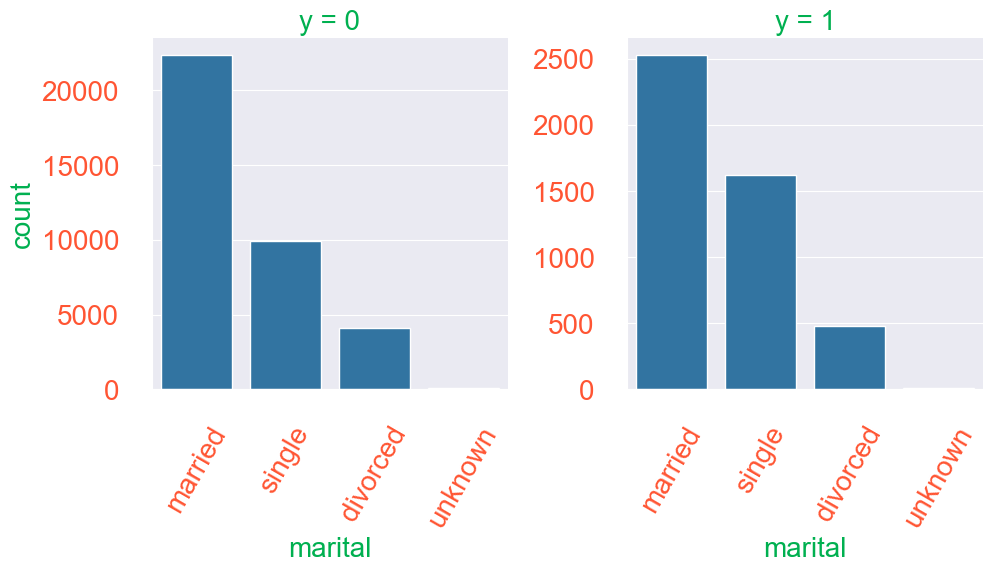

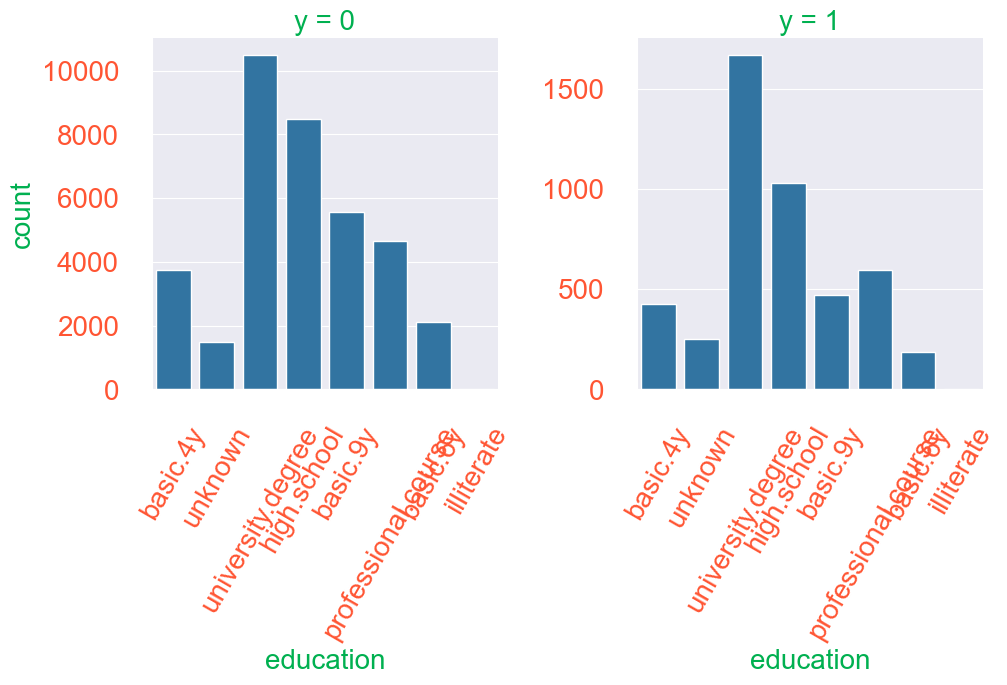

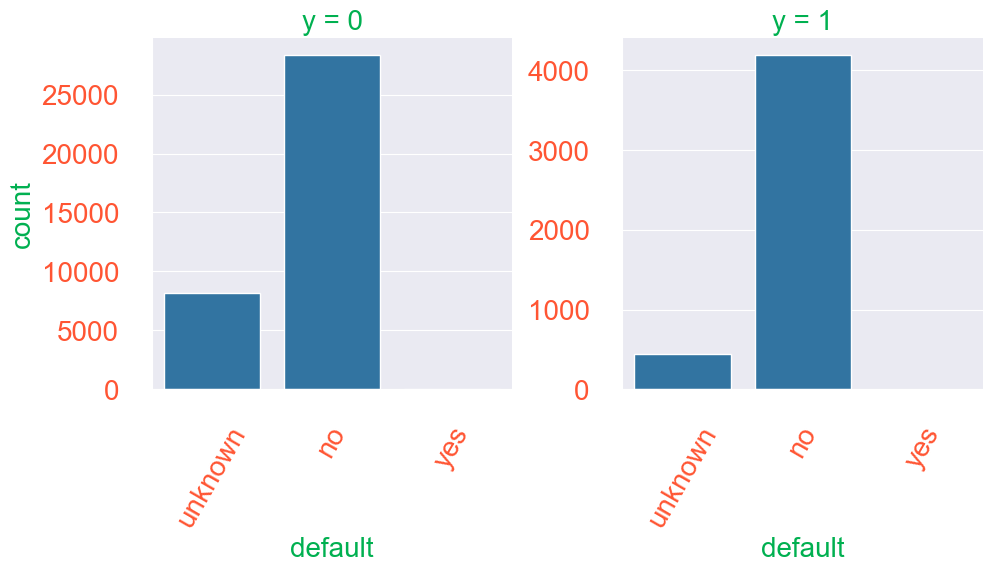

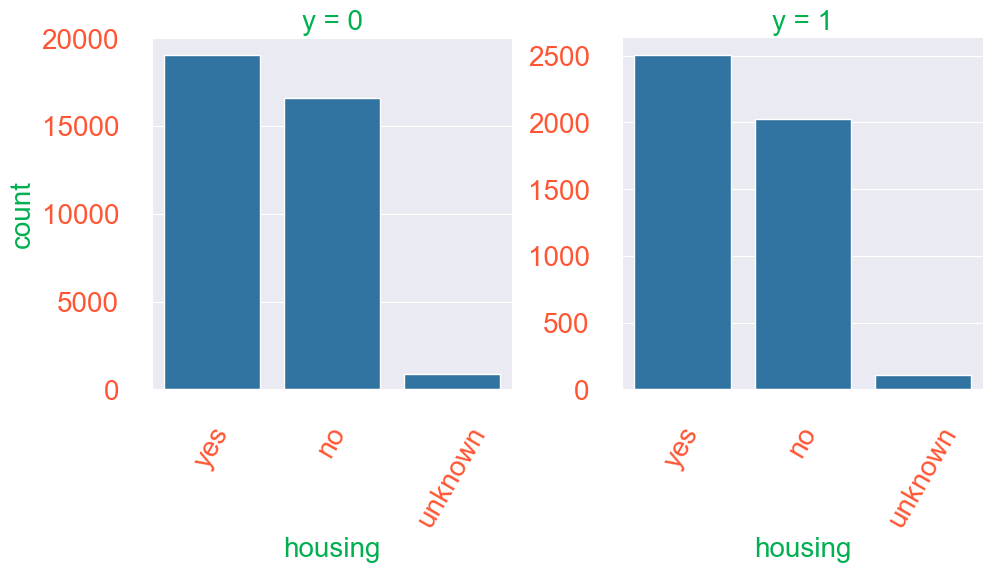

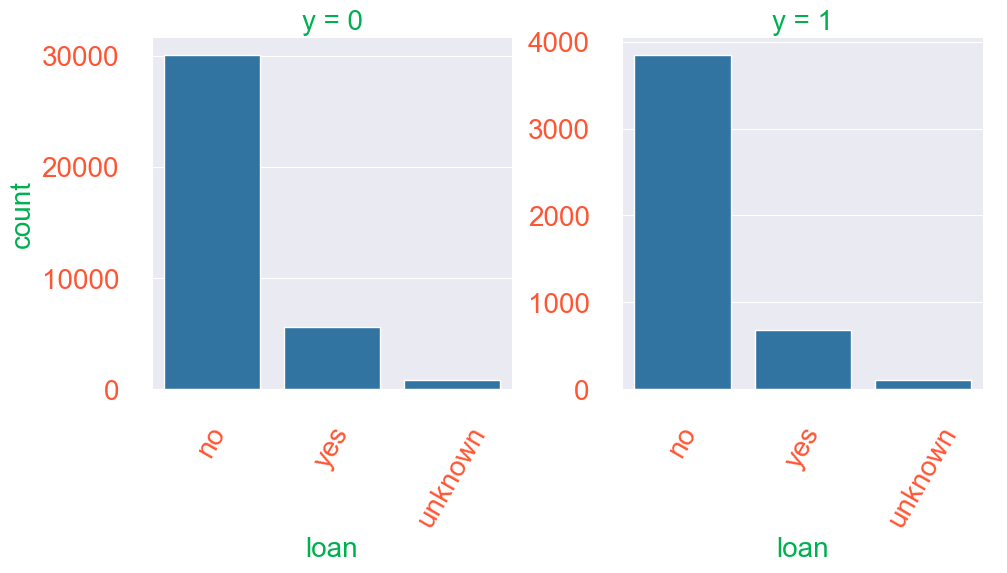

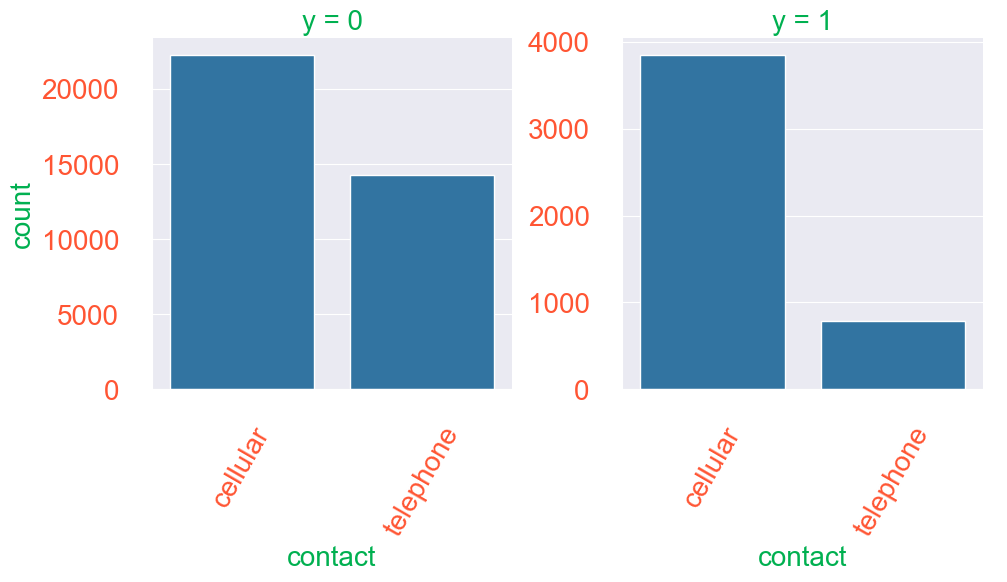

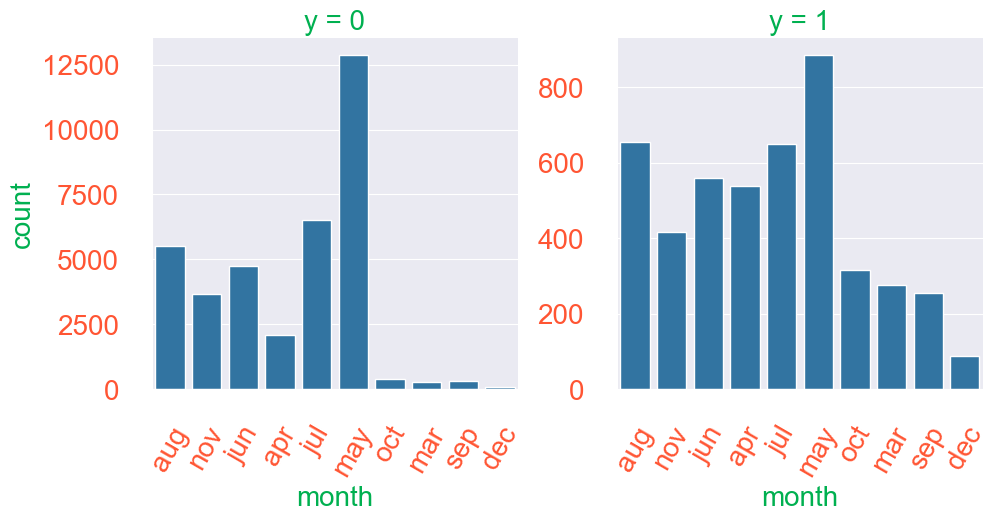

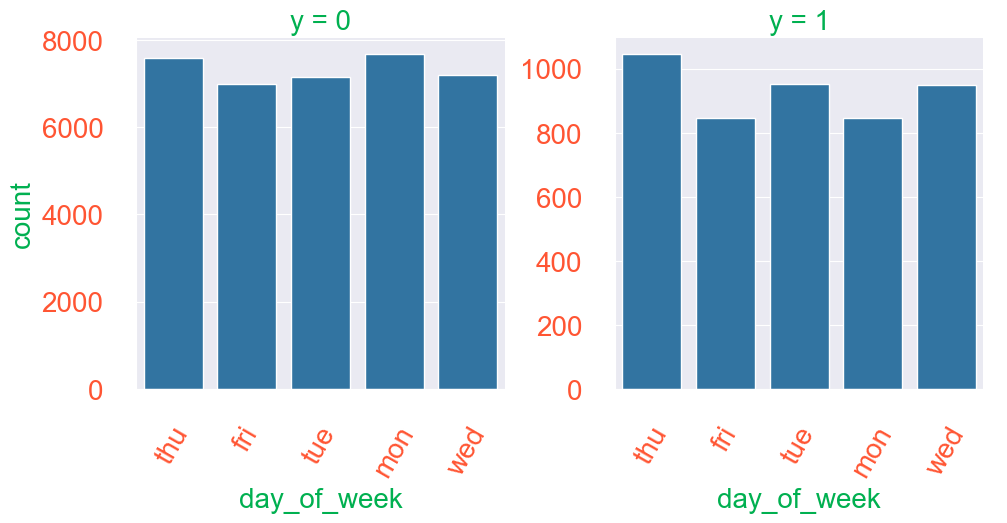

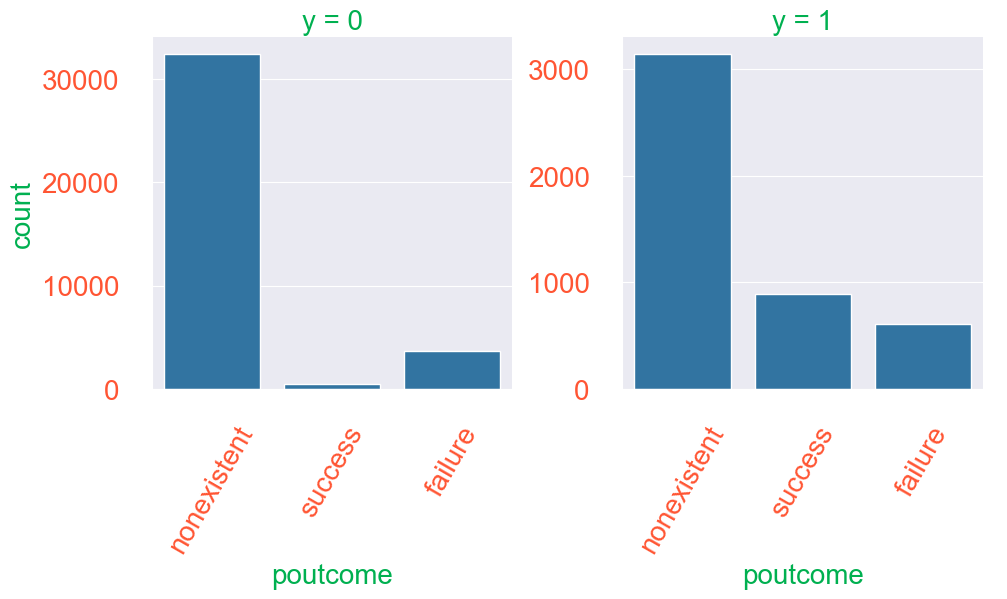

In [20]:
### Гистограммы распределений в разных классах

for col in categorical_columns:
    g = sns.catplot(x=col, kind='count', col='y', data=df, sharey=False)
    g.set_xticklabels(rotation=60)

In [21]:
df = df.drop(['loan', 'housing', 'marital'], axis=1)
categorical_columns = categorical_columns.drop(['loan', 'housing', 'marital'])

In [22]:
df.head().shape

(5, 15)

### Закодируем оставшиеся категориальные фичи!

In [23]:
### Посмотрим, какие можно кодировать с помощью one-hot метода,
### а для каких лучше посчитать счетчики!

df.describe(include='object')

,job,education,default,contact,month,day_of_week,poutcome
count,41188,41188,41188,41188,41188,41188,41188
unique,12,8,3,2,10,5,3
top,admin.,university.degree,no,cellular,may,thu,nonexistent
freq,10422,12168,32588,26144,13769,8623,35563


In [24]:
for col in categorical_columns:

    ### К колонкам с маленькой размерностью применим one-hot
    if df[col].nunique() < 5:
        one_hot = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat((df.drop(col, axis=1), one_hot), axis=1)

    ### К остальным - счетчики
    else:
        mean_target = df.groupby(col)['y'].mean()
        df[col] = df[col].map(mean_target)

In [25]:
df.head()

,age,job,education,month,day_of_week,campaign,pdays,previous,cons_price_idx,cons_conf_idx,nr_employed,y,default_unknown,default_yes,contact_telephone,poutcome_nonexistent,poutcome_success
0,44,0.068943,0.102490,0.106021,0.121188,1,999,0,93.444,-36.1,5228.1,0,True,False,False,True,False
1,53,0.108260,0.145003,0.101439,0.108087,1,999,0,93.200,-42.0,5195.8,0,False,False,False,True,False
2,28,0.112175,0.137245,0.105115,0.121188,3,6,2,94.055,-39.8,4991.6,1,False,False,False,False,True
3,39,0.081381,0.108355,0.204787,0.108087,2,999,0,93.075,-47.1,5099.1,0,False,False,False,True,False
4,55,0.252326,0.102490,0.106021,0.108087,1,3,1,92.201,-31.4,5076.2,1,False,False,False,False,True


In [26]:
X = df.drop('y', axis=1)
Y = df['y']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y,
                                                    random_state=0,
                                                    test_size=0.2)

In [28]:
X_train.shape[0], X_test.shape[0]

(32950, 8238)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([('scaler', StandardScaler()),
                 ('LR', LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000))])

pipe.fit(X_train, Y_train)

,steps,"[('scaler', ...), ('LR', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,None
,dual,False
,tol,0.0001
,C,1.0


In [30]:
### Pipeline автоматом для классификации отображает accuracy

pipe.score(X_test, Y_test)

0.9013109978150037

In [31]:
X_test.head(1)

,age,job,education,month,day_of_week,campaign,pdays,previous,cons_price_idx,cons_conf_idx,nr_employed,default_unknown,default_yes,contact_telephone,poutcome_nonexistent,poutcome_success
15500,51,0.068943,0.078246,0.204787,0.099483,4,999,0,93.075,-47.1,5099.1,False,False,False,True,False


In [32]:
### Чтобы предсказать вероятности соответственно классам
### Обратимся к аттрибуту classes_ и к методу predict_proba
### А чтобы понять уверенность модели, воспользуемся методом
### decision_function

print(pipe.classes_)

print(pipe.predict(X_test.head(1)))

print(pipe.predict_proba(X_test.head(1)))

print(pipe.decision_function(X_test.head(2)))

[0 1]
[0]
[[0.8814013 0.1185987]]
[-2.00576745 -2.25764275]


In [33]:
### Константное предсказание на тесте

np.mean(Y_test == 0)

np.float64(0.8891721291575625)

In [34]:
df['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

In [35]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(Y_test, pipe.predict(X_test)).ravel()

print(f'True Negative errors: {tn}')
print(f'False Positive errors: {fp}')
print(f'False Negative errors: {fn}')
print(f'True Positive errors: {tp}')

True Negative errors: 7208
False Positive errors: 117
False Negative errors: 696
True Positive errors: 217


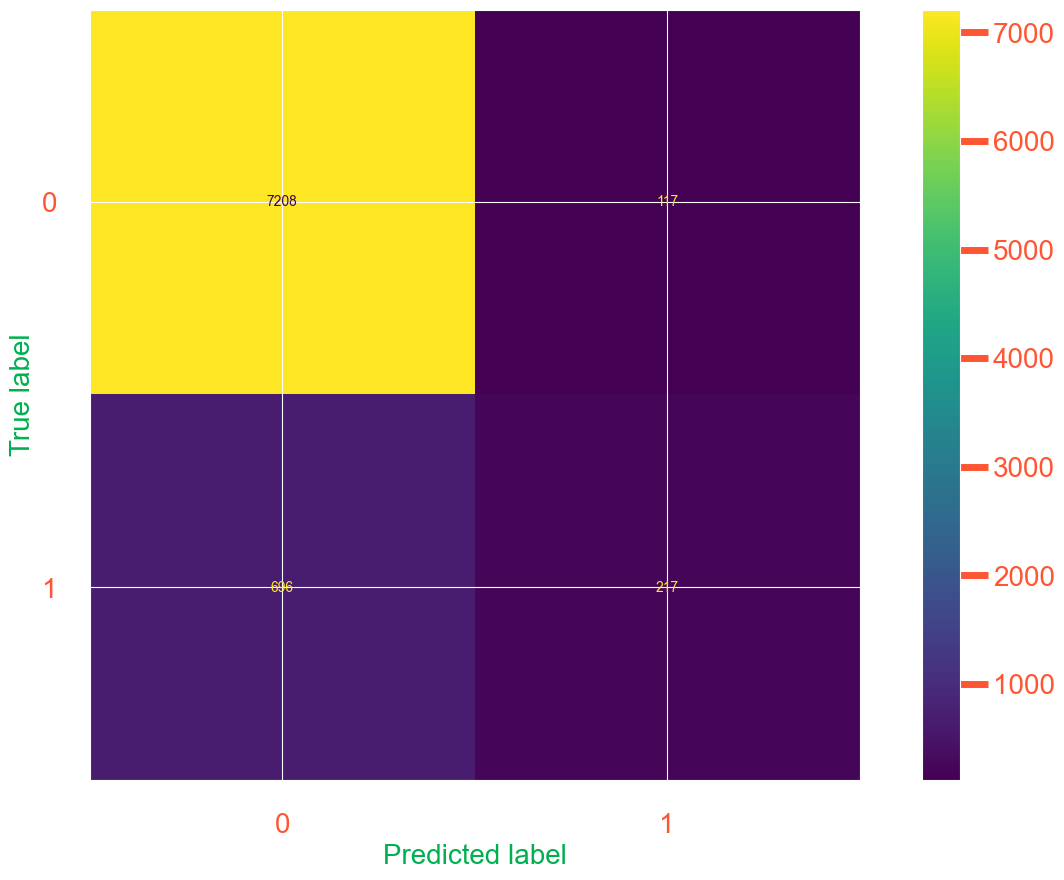

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, pipe.predict(X_test), labels=pipe.classes_)

cmp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(16, 10))

cmp.plot(ax=ax)
plt.show()

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print(f'accuracy = {accuracy_score(Y_test, pipe.predict(X_test)):.3f}')
print(f'precision = {precision_score(Y_test, pipe.predict(X_test)):.3f}')
print(f'recall = {recall_score(Y_test, pipe.predict(X_test)):.3f}')
print(f'f1 = {f1_score(Y_test, pipe.predict(X_test)):.3f}')

accuracy = 0.901
precision = 0.650
recall = 0.238
f1 = 0.348


In [38]:
pipe.predict_proba(X_test.head(1))[:, 1]

array([0.1185987])

In [39]:
from sklearn.metrics import precision_recall_curve

precision_recall_curve(Y_test, pipe.predict_proba(X_test)[:, 1])


(array([0.11082787, 0.11084133, 0.11085478, ..., 1.        , 1.        ,
        1.        ], shape=(7813,)),
 array([1.        , 1.        , 1.        , ..., 0.00219058, 0.00109529,
        0.        ], shape=(7813,)),
 array([0.00292011, 0.00323579, 0.00434602, ..., 0.9046428 , 0.90522311,
        0.90809827], shape=(7812,)))

In [40]:
precision, recall, thresholds = precision_recall_curve(Y_test, pipe.predict_proba(X_test)[:, 1])

den = precision + recall
f_scores = np.where(den > 0, 2 * precision * recall / den, 0.0)
best_index = np.argmax(f_scores)
print("Best F-scope: ", f_scores[best_index])
print("thresholds for best F-scope: ", thresholds[best_index])

Best F-scope:  0.4751703992210321
thresholds for best F-scope:  0.18446668514750275


In [41]:
precision[best_index]

np.float64(0.42769500438212094)

In [42]:
recall[best_index]

np.float64(0.5345016429353778)

In [43]:
threshold = thresholds[best_index]
y_pred = (pipe.predict_proba(X_test)[:,1] > threshold).astype('float')
y_pred

array([0., 0., 0., ..., 0., 0., 0.], shape=(8238,))

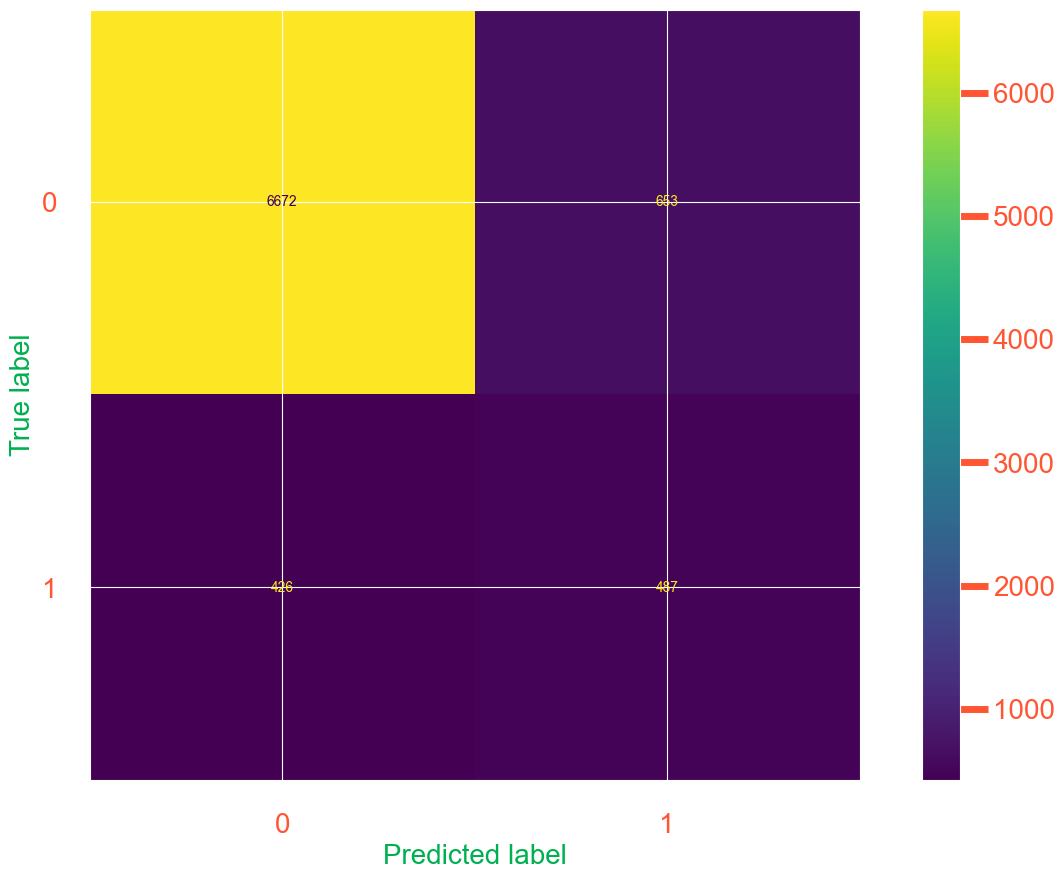

In [44]:
cm = confusion_matrix(Y_test, y_pred, labels=pipe.classes_)

cmp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(16, 10))

cmp.plot(ax=ax)
plt.show()

In [45]:
from sklearn.metrics import roc_curve

frp, tpr, thresholds = roc_curve(Y_test, pipe.predict_proba(X_test)[:,1])

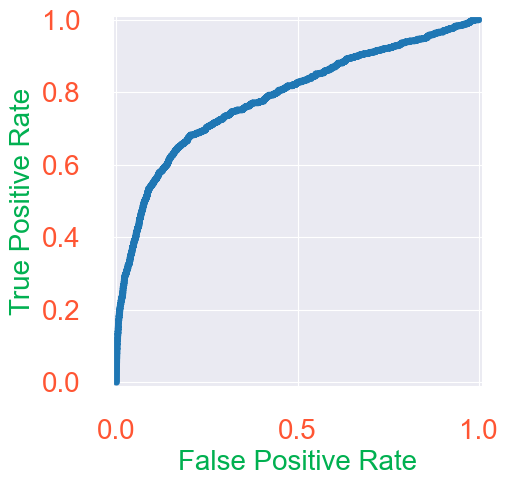

In [46]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay(fpr=frp, tpr=tpr).plot()

In [47]:
from sklearn.metrics import auc

auc(frp, tpr)


0.7856283713818973

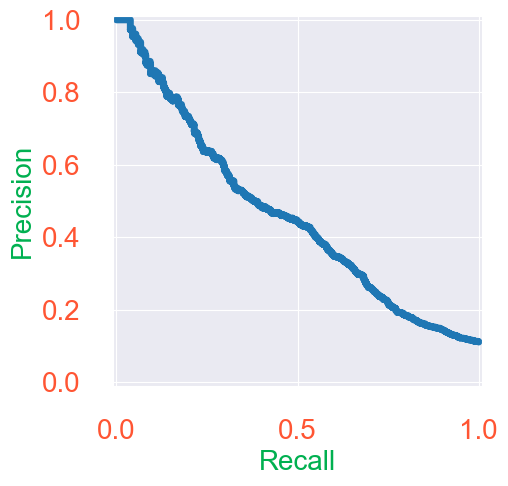

In [48]:
from sklearn.metrics import PrecisionRecallDisplay
precision, recall, thresholds = precision_recall_curve(Y_test, pipe.predict_proba(X_test)[:, 1])

PrecisionRecallDisplay(precision=precision, recall=recall).plot()

In [49]:
auc(recall, precision)

0.4603788059079619

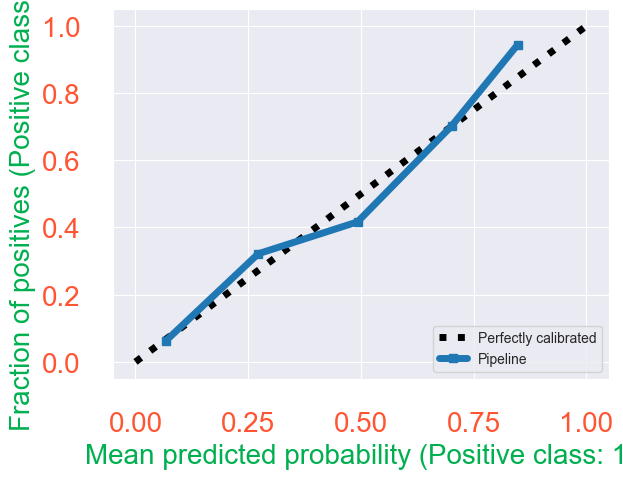

In [50]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(pipe, X_test, Y_test)

In [51]:
pipe.predict_proba(X_test.head(1))

array([[0.8814013, 0.1185987]])

## SVM

In [52]:
from sklearn.svm import LinearSVC

pipe_svm = Pipeline([("scaler_svm", StandardScaler()), ("SVM", LinearSVC())])

pipe_svm.fit(X_train, Y_train)

pipe_svm.score(X_test, Y_test)

0.9025248846807478

In [53]:
### Precision / Recall / F-мера

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


print(f'Accuracy равно: {accuracy_score(Y_test, pipe_svm.predict(X_test)):.3f}' )

print(f'Precision равно: {precision_score(Y_test, pipe_svm.predict(X_test)):.3f}' )

print(f'Recall равно: {recall_score(Y_test, pipe_svm.predict(X_test)):.3f}' )

print(f'F-мера равно: {f1_score(Y_test, pipe_svm.predict(X_test)):.3f}' )

Accuracy равно: 0.903
Precision равно: 0.688
Recall равно: 0.220
F-мера равно: 0.334


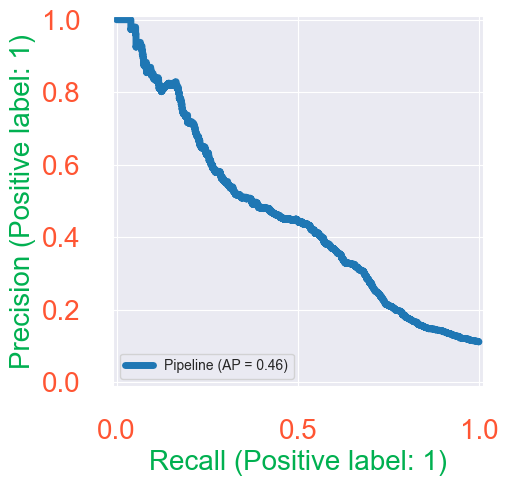

In [54]:
PrecisionRecallDisplay.from_estimator(pipe_svm, X_test, Y_test)

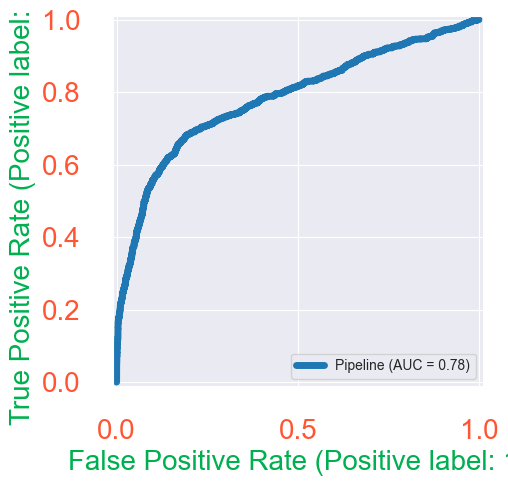

In [55]:
RocCurveDisplay.from_estimator(pipe_svm, X_test, Y_test)

In [56]:
### Изобразим калибровочную кривую
### Сейчас все сломается!

CalibrationDisplay.from_estimator(pipe_svm, X_test, Y_test)

AttributeError: Pipeline has none of the following attributes: predict_proba.

In [ ]:
### Преобраузем выходы модели в вероятности
pipe_svm.decision_function(X_test.head(2))

def sigmoid(output):
    return 1 / (1 + np.exp(-output))

sigmoid(pipe_svm.decision_function(X_test))
pred_prob = sigmoid(pipe_svm.decision_function(X_test))

In [ ]:
min(pred_prob), max(pred_prob)

In [ ]:

CalibrationDisplay.from_predictions(Y_test, pred_prob, n_bins=15)

In [1]:
### Калибровка Плата

from sklearn.calibration import CalibratedClassifierCV

calibration = CalibratedClassifierCV(pipe_svm, cv=5, method='sigmoid')
calibration.fit(X_train, Y_train)

calibrated_probs = calibration.predict_proba(X_test)[:, 1]

NameError: name 'pipe_svm' is not defined

In [ ]:
calibrated_probs

In [ ]:
CalibrationDisplay.from_predictions(Y_test, calibrated_probs, n_bins=15)